In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("reddit_features.csv")
df.head()

,title,score,upvote_ratio,num_comments,created_utc,subreddit,is_self,awards,url,post_hour,post_day,is_weekend,title_words_count,has_question,has_number,controversy_index,sentiment_score,is_extreme_sentiment,viral
0,The Removed DOGE Deposition Videos Have Alread...,55179,0.97,1016,1.773538e+09,technology,0,0,https://www.404media.co/the-removed-doge-depos...,1,6,1,47,0,0,0.207738,0.0258,0,1
1,ChatGPT uninstalls surged by 295% after DoD deal,43096,0.96,1286,1.772496e+09,technology,0,0,https://techcrunch.com/2026/03/02/chatgpt-unin...,0,1,0,8,0,1,0.286403,0.0000,0,1
2,1.5 Million Users Leave ChatGPT,38902,0.96,1525,1.772563e+09,technology,0,0,https://www.forbes.com/sites/barrycollins/2026...,18,1,0,5,0,1,0.293216,-0.0516,0,1
3,‘Another internet is possible’: Norway rails a...,35918,0.97,1463,1.773662e+09,technology,0,0,https://www.theguardian.com/world/2026/mar/16/...,11,0,0,8,0,0,0.218668,0.0000,0,1
4,DOGE employee stole Social Security data and p...,35822,0.97,838,1.773174e+09,technology,0,0,https://techcrunch.com/2026/03/10/doge-employe...,20,1,0,15,0,0,0.201966,0.3400,0,1


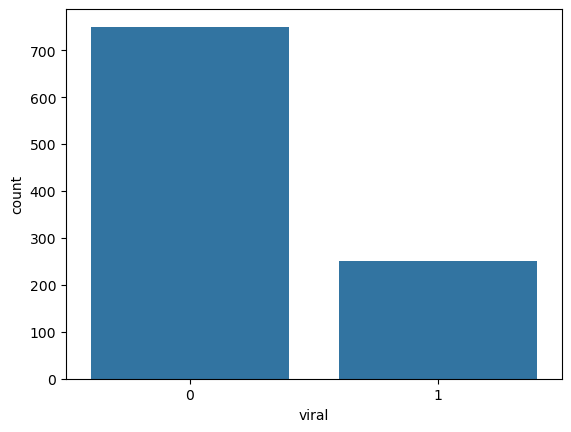

In [5]:
sns.countplot(x="viral", data = df)
plt.show()

750 non-viral vs 250 viral posts 75/25 split.
Class imbalance needs to be handled during model training using class_weight.

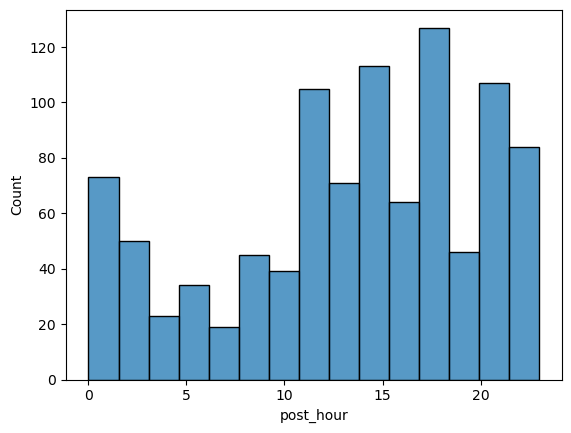

In [9]:
sns.histplot(x = "post_hour", data=df)
plt.show()

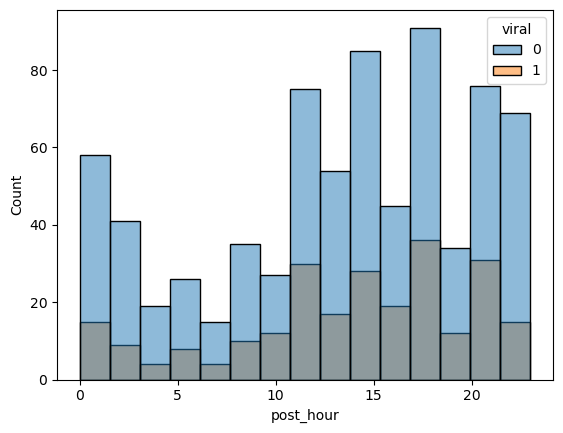

In [10]:
sns.histplot(x = "post_hour",hue="viral", data=df)
plt.show()

Posts during evening hours (UTC 17-18) are more frequent and tend to have higher engagement.
Timing matters when a post is published affects its virality.

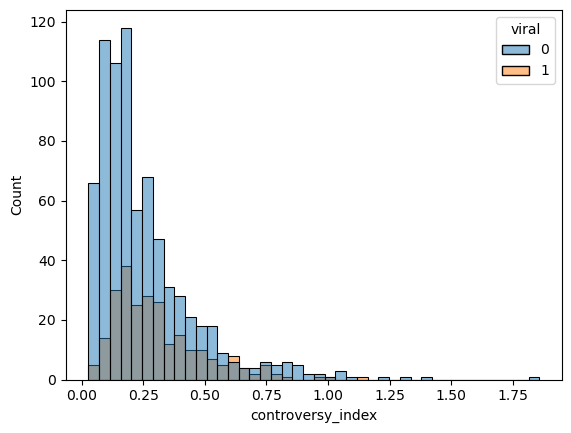

In [13]:
sns.histplot(x = "controversy_index",hue="viral" ,data=df)
plt.show()

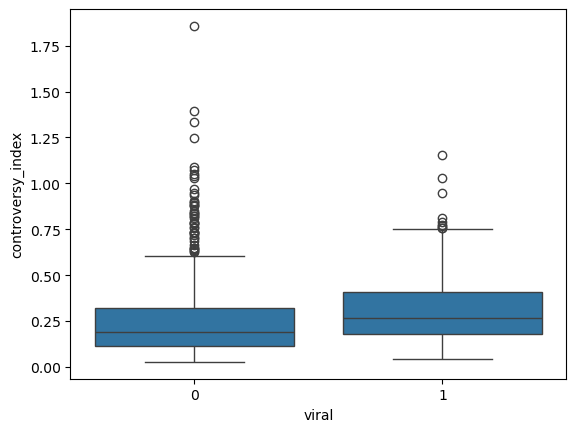

In [14]:
sns.boxplot(x="viral", y="controversy_index", data=df)
plt.show()

Boxplot shows that viral and non-viral posts have similar controversy_index medians.
Not a strong standalone predictor

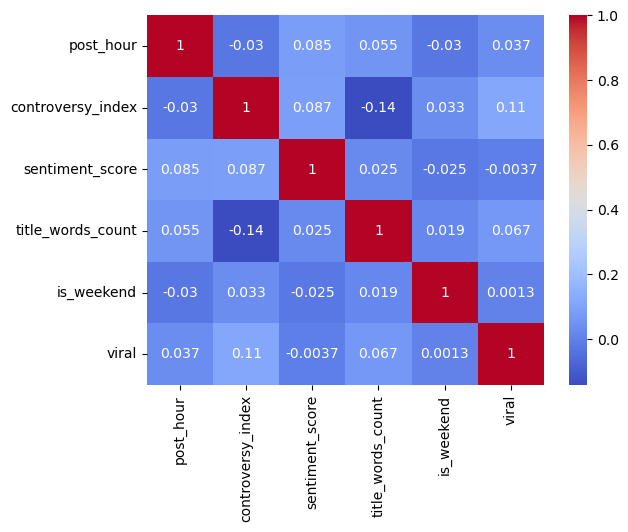

In [16]:
correlation = df[["post_hour", "controversy_index", "sentiment_score", 
                   "title_words_count", "is_weekend", "viral"]].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

No single feature has strong correlation with virality (highest is controversy_index at 0.11).
ML model needed to combine all features together for better prediction.